In [2]:
#Run imports for libraries to be used
import pandas as pd
import json

from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from pandas.core.common import random_state
from sklearn.base import BaseEstimator
from sklearn.experimental import enable_iterative_imputer
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import PowerTransformer
import re
import missingno as msno
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
import sklearn
from scipy.cluster.hierarchy import fcluster
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import ADASYN, RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import FunctionTransformer
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.base import TransformerMixin

#Set up options for pandas return functions
pd.options.display.max_rows = 100
pd.options.display.max_columns = 110
sklearn.set_config(transform_output="pandas")

In [3]:
def load_data():
    #load the schema
    with open('ingest_schema.json') as f:
        schema = json.load(f)

    #Use the schema and other params to ingest the csv
    df = pd.read_csv(
        filepath_or_buffer ="CW_data.csv",
        encoding='ANSI',
        dtype = schema,
        true_values = ["positive", "detected", "TRUE", 'present'],
        false_values = ["negative", "not_detected", "FALSE", 'absent'],
        na_values = ["not_done", "<NA>"],
        on_bad_lines = "warn"
        )
    # Remove occurrences of \xa0
    df.columns = [re.sub(r'\s+', ' ', col).strip() for col in df.columns]
    # drop useless columns
    df.drop('Patient ID', axis = 1, inplace = True)
    df_single_values =  df.loc[:, df.nunique(dropna = False) == 1]
    df = df.drop(columns = df_single_values.columns)
    #Ignore the patient quantile and exam result and drop rows that have all other feats as NaN
    ignored_cols = ["Patient age quantile", "SARS-Cov-2 exam result"]
    all_feats_cols = df.columns.difference(ignored_cols)
    df = df.dropna(how = "all", subset = all_feats_cols)
    # Handle categoric and other dtype columns
    df['feat_Urine - Leukocytes'] = df['feat_Urine - Leukocytes'].replace('<1000', 999).astype('Float64')
    mapping = { 'normal': 0, 'Ausentes' : 0}
    df = df.replace(mapping)
    #columns that have categorical data with unknown relationships i.e. if ordinal or not.
    # categorical_cols = ['feat_Urine - Aspect','feat_Urine - Crystals','feat_Urine - Color']
    # # utilise one-hot encoding to make these columns split out into numeric values columns instead.
    # df = pd.get_dummies(
    #                 df,
    #                 columns = categorical_cols,
    #                 dummy_na = True,
    #                 prefix = categorical_cols,
    #                 dtype = 'boolean'
    #                 )
    # df = df.apply(pd.to_numeric)
    return df

In [4]:
def tt_split(df, size):
    df_classifiers = df['SARS-Cov-2 exam result']
    df_predictors = df.drop(['SARS-Cov-2 exam result'], axis = 1).copy()
    df_predictor_train, df_predictor_test, df_classifier_train, df_classifier_test = train_test_split(df_predictors, df_classifiers, test_size = size, stratify = df_classifiers, random_state = 1)
    return df_predictor_train, df_predictor_test, df_classifier_train, df_classifier_test

In [5]:
def one_hot_encoder(dfx, dfx_test):
    #columns that have categorical data with unknown relationships i.e. if ordinal or not.
    categorical_cols = ['feat_Urine - Aspect','feat_Urine - Crystals','feat_Urine - Color']
    #convert to all singular column dtype to make ohencoder happy
    train_converted = dfx[categorical_cols].astype(str).replace('nan', 'missing')
    test_converted = dfx_test[categorical_cols].astype(str).replace('nan', 'missing')
    # utilise one-hot encoding to make these columns split out into numeric values columns instead.
    encoder = OneHotEncoder(handle_unknown = 'ignore', dtype = 'bool', sparse_output= False)
    encoded_train = encoder.fit_transform(train_converted)
    encoded_test = encoder.transform(test_converted)
    #df conversion
    encoded_cols = encoder.get_feature_names_out(categorical_cols)
    dfx_encoded = pd.DataFrame(encoded_train, columns = encoded_cols, index = dfx.index)
    dfx_test_encoded = pd.DataFrame(encoded_test, columns = encoded_cols, index = dfx_test.index)
    #add to og dataframes
    dfx_new = dfx.drop(columns = categorical_cols).join(dfx_encoded)
    dfx_test_new = dfx_test.drop(columns = categorical_cols).join(dfx_test_encoded)
    return dfx_new, dfx_test_new

In [6]:
def pipe_one_hot_encoder():
    #columns that have categorical data with unknown relationships i.e. if ordinal or not.
    categorical_cols = ['feat_Urine - Aspect','feat_Urine - Crystals','feat_Urine - Color']
    # deal with nan and set up encoder
    one_hot_trans = Pipeline(steps = [
        ('impute_nan', FunctionTransformer(lambda df: df.astype(str).replace('nan', 'missing'))),
        ('one_hot', OneHotEncoder(handle_unknown = 'ignore', dtype = 'bool', sparse_output= False))
    ])
    return ColumnTransformer(
        transformers = [
            ('categoric', one_hot_trans, categorical_cols)
        ],
        remainder = 'passthrough',
        verbose_feature_names_out = False
    ).set_output(transform = "pandas")

In [7]:
# inputs: threshold - integer between 0 and 1, corresponding to percent to drop (0.05 = 95%)
def missingness_thresholder(df_train,df_test, threshold):
    df_train.dropna(axis = 1, inplace=True, thresh = int(threshold * len(df_train)))
    keep_cols = df_train.columns
    df_test.drop(inplace = True, columns = df_test.columns.difference(keep_cols))
    return df_train, df_test

In [8]:
class MissingnessThresholder(BaseEstimator, TransformerMixin):
    def __init__(self, threshold = 0.03):
        self.threshold = threshold
        self.keep_cols = None

    def fit(self, X, y = None):
        threshold_val = int(self.threshold * len(X))
        df_temp = X.dropna(axis = 1, thresh = threshold_val)
        self.keep_cols = df_temp.columns
        return self

    def transform(self, X):
        return X[self.keep_cols]

    def get_feature_names_out(self, input_features = None):
        return self.keep_cols

In [9]:
def missingness_imputer(df_train,df_test, imputer_type = None, imputer_strategy = None):
    boolean_cols = df_train.select_dtypes(include = 'boolean').columns
    if imputer_type == 'iterative':
        imputer = IterativeImputer(max_iter = 50, random_state = 1, initial_strategy = imputer_strategy)
        imputer.set_output(transform = "pandas")
        imputer.fit(df_train)
        df_train_imputed = imputer.transform(df_train)
        df_test_imputed = imputer.transform(df_test)
    elif imputer_type == 'simple':
        imputer = SimpleImputer(strategy = imputer_strategy)
        imputer.set_output(transform = "pandas")
        imputer.fit(df_train)
        df_train_imputed = imputer.transform(df_train)
        df_test_imputed = imputer.transform(df_test)
    else:
        df_train = df_train.astype('float64')
        df_test = df_test.astype('float64')
        df_train.fillna(value = 0, inplace = True)
        df_test.fillna(value = 0, inplace = True)
        return df_train, df_test
    df_train_imputed[boolean_cols] = df_train_imputed[boolean_cols].astype(bool)
    df_test_imputed[boolean_cols] = df_test_imputed[boolean_cols].astype(bool)
    return df_train_imputed, df_test_imputed

In [10]:
def pipe_missingness_imputer(imputer_type = 'simple', imputer_strategy = 'median'):
    if imputer_type == 'iterative':
        base_imputer = IterativeImputer(
            max_iter = 50,
            random_state = 1,
            initial_strategy = imputer_strategy)
    elif imputer_type == 'simple':
        base_imputer = SimpleImputer(strategy=imputer_strategy)
    else:
        base_imputer = SimpleImputer(strategy = 'constant', fill_value = 0)

    def return_to_bool(X):
        for col in X.columns:
            unique_values = X[col].unique()
            if set(unique_values).issubset({0.0, 1.0, 0, 1}):
                X[col] = X[col].astype(bool)
        return X

    #sub pipeline to impute and bool cast
    imputer = Pipeline([
        ('impute', base_imputer),
        ('recast', FunctionTransformer(return_to_bool)),
    ])
    imputer.set_output(transform = "pandas")
    return imputer


In [11]:
def skew_transformer(df_train,df_test):
    transformer = PowerTransformer(method = 'yeo-johnson')
    transformer.set_output(transform="pandas")
    numeric_cols = df_train.select_dtypes(exclude = ['boolean']).columns
    train_trans = transformer.fit_transform(df_train[numeric_cols].astype(float))
    test_trans = transformer.transform(df_test[numeric_cols].astype(float))
    df_train[numeric_cols] = train_trans
    df_test[numeric_cols] = test_trans
    return df_train, df_test

In [12]:
def pipe_skew_transformer():
    preprocessor = ColumnTransformer([
        ('skew', PowerTransformer(method = 'yeo-johnson'),
        make_column_selector(dtype_exclude = ['bool']))
    ],
    remainder = 'passthrough',
    verbose_feature_names_out= False)
    preprocessor.set_output(transform = "pandas")
    return preprocessor

In [13]:
def constant_col_drop(df_train,df_test):
    constant_cols = df_train.columns[df_train.nunique() <= 1].tolist()
    df_train.drop(constant_cols, axis = 1, inplace = True)
    df_test.drop(constant_cols, axis = 1, inplace = True)
    return df_train, df_test

In [14]:
class ConstantColDropper(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.cols_to_drop = []
    def fit(self, X):
        self.cols_to_drop = X.columns[X.nunique() <= 1].tolist()
        return self
    def transform(self, X):
        return X.drop(columns = self.cols_to_drop)
    def get_feature_names_out(self, input_features = None):
        if input_features is None:
            return None
        return [feat for feat in input_features if feat not in self.cols_to_drop]

In [15]:
def pca_reduction(df_train,df_test, components):
    pca = PCA(n_components = components)
    pca.set_output(transform = "pandas")
    df_train_pca = pca.fit_transform(df_train)
    df_test_pca = pca.transform(df_test)
    return df_train_pca, df_test_pca

In [16]:
def pipe_pca_reduction(n_components = 5):
    pca = PCA(n_components = n_components)
    pca.set_output(transform = "pandas")
    return pca

In [17]:
def oversampler(df_train,df_classifier, oversampler_type, oversampler_strategy):
    if oversampler_type == 'random':
        oversampler = RandomOverSampler(random_state = 1)
        df_train_oversampled, df_classifier_oversampled = oversampler.fit_resample(df_train, df_classifier)
    elif oversampler_type == 'smote':
        oversampler = SMOTE(sampling_strategy = oversampler_strategy, random_state =1)
        df_train_oversampled, df_classifier_oversampled = oversampler.fit_resample(df_train, df_classifier)
    elif oversampler_type == 'adasyn':
        oversampler = ADASYN(random_state = 1)
        df_train_oversampled, df_classifier_oversampled = oversampler.fit_resample(df_train, df_classifier)
    else:
        print('Invalid oversampler type')
        return df_train, df_classifier
    return df_train_oversampled, df_classifier_oversampled

In [18]:
def pipe_oversampler(oversampler_type = 'random', oversampler_strategy = 'minority'):
    if oversampler_type == 'random':
        return RandomOverSampler(random_state = 1, sampling_strategy = oversampler_strategy)
    elif oversampler_type == 'smote':
        return SMOTE(sampling_strategy = oversampler_strategy, random_state = 1)
    elif oversampler_type == 'adasyn':
        return ADASYN(random_state = 1)
    else:
        return 'passthrough'

In [36]:
# builds models quickly with only specific preprocessing enabled
def preprocess(
        dfx,
        dfy,
        dfx_test,
        msn_thresh = False,
        msn_thresh_val = None,
        impute = False,
        imputer_type = None,
        imputer_strategy = None,
        unskew = False,
        pca_reduce = False,
        pca_components = None,
        oversample = False,
        oversampling_type = None,
        oversampling_strategy = None,
        ):
    if msn_thresh:
        dfx, dfx_test = missingness_thresholder(dfx, dfx_test, msn_thresh_val)
    if impute:
        dfx, dfx_test = missingness_imputer(df_train = dfx,  df_test = dfx_test, imputer_type= imputer_type,imputer_strategy= imputer_strategy)
    if unskew:
        dfx, dfx_test = skew_transformer(dfx, dfx_test)
        dfx, dfx_test = constant_col_drop(dfx, dfx_test)
    if pca_reduce:
        dfx, dfx_test = pca_reduction(dfx, dfx_test, pca_components)
    if oversample:
        dfx, dfy = oversampler(dfx, dfy, oversampling_type, oversampling_strategy)
    return dfx, dfx_test, dfy


In [20]:
def model_predict(fitted_model, dfx_test, dfy_test):
    predictions = fitted_model.predict(dfx_test)
    score = fitted_model.score(dfx_test, dfy_test)
    f1 = f1_score(predictions, dfy_test, average = 'macro')
    model_name = fitted_model.__class__.__name__
    print(f'{model_name} score is \n{score}\n{model_name} f1 is \n{f1}')
    return predictions, score, f1, model_name

In [21]:
def compare_models(models, dfx_test, dfy_test):
    results = []
    for model in models:
        predictions, score, f1, model_name = model_predict(model, dfx_test, dfy_test)
        results.append({
            'Model': model_name,
            'Accuracy': score,
            'F1-Score': f1
        })
    # build a melted df to plot results.
    df_results = pd.DataFrame(results)
    df_plot = df_results.melt(id_vars='Model', var_name='Metric', value_name='Value')
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_plot, x='Model', y='Value', hue='Metric')
    plt.title('Single TT Split Model Performance Comparison')
    plt.ylim(0, 1.1) # keep axis locked at 0 - 1 so comparisons are easier
    plt.ylabel('Score')
    plt.grid(axis='y', linestyle='-')
    plt.show()

    return df_results


In [22]:
def print_cm(dfy_test, predictions, model_name):
    cm = confusion_matrix(dfy_test, predictions)
    plt.figure(figsize = (5,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted Covid Result')
    plt.ylabel('True Covid Result')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

## Basline with brute force cross val
baseline preprocessing steps:
* drop all nan cols/rows
* handle mapping non numeric cols
* one hot encoding

C:\Users\Jess\AppData\Local\Temp\ipykernel_16804\2663247358.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapping)


Model RandomForestClassifier cross val fold score is 
0.5023348665346068
Model XGBClassifier cross val fold score is 
0.5662162825277093
Model BalancedRandomForestClassifier cross val fold score is 
0.5604474636791493
RandomForestClassifier score is 
0.9063545150501672
RandomForestClassifier f1 is 
0.5377650176678446
XGBClassifier score is 
0.903010033444816
XGBClassifier f1 is 
0.6203091474361782
BalancedRandomForestClassifier score is 
0.6989966555183946
BalancedRandomForestClassifier f1 is 
0.5671963458569222


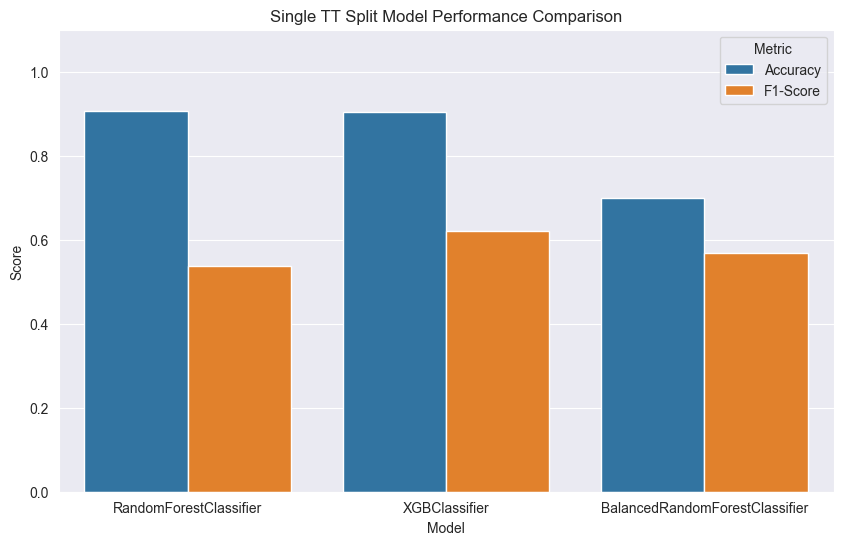

,Model,Accuracy,F1-Score
0,RandomForestClassifier,0.906355,0.537765
1,XGBClassifier,0.903010,0.620309
2,BalancedRandomForestClassifier,0.698997,0.567196


In [38]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
results = {}
dfx, dfx_test, dfy ,dfy_test = tt_split(load_data(),0.2)
dfx, dfx_test = one_hot_encoder(dfx,dfx_test)
fitted_models = []
unfitted_models = [
    RandomForestClassifier(),
    XGBClassifier(),
    BalancedRandomForestClassifier(),
    #KNeighborsClassifier(n_neighbors = 5)

]

for model in unfitted_models:
    model_name = model.__class__.__name__
    fold_scores = []
    for train_index, test_index in skf.split(dfx, dfy):
        x_train, x_test = dfx.iloc[train_index].copy(), dfx.iloc[test_index].copy()
        y_train, y_test = dfy.iloc[train_index].copy(), dfy.iloc[test_index].copy()
        processed_x_train, processed_x_test, processed_y_train = preprocess(
        dfx = x_train,
        dfx_test= x_test,
        dfy = y_train
        )
        model.fit(processed_x_train, processed_y_train)
        predictions = model.predict(processed_x_test)
        fold_scores.append(f1_score(y_test, predictions, average = 'macro'))
    results[model_name] = np.mean(fold_scores)
    print(f'Model {model_name} cross val fold score is \n{results[model_name]}')


processed_dfx, processed_dfx_test, processed_dfy = preprocess(dfx = dfx,
                                                              dfx_test= dfx_test,
                                                              dfy = dfy
                                                              )
for unfitted_model in unfitted_models:
    #run_cross_val(unfitted_model, processed_dfx, processed_dfy)
    unfitted_model.fit(processed_dfx, processed_dfy)
    fitted_models.append(unfitted_model)
compare_models(fitted_models, processed_dfx_test, dfy_test)

## All preprocessing enabled, no hyper tuning
Preprocessing:
* baseline steps
* remove cols with more than 97% missing values
* impute missing values with simple median
* unskew via yeo-johnson
* pca with 5 components
* oversample at random


C:\Users\Jess\AppData\Local\Temp\ipykernel_16804\2663247358.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapping)


Model RandomForestClassifier cross val fold score is 
0.5455593972732553
Model XGBClassifier cross val fold score is 
0.5485381426732047
Model BalancedRandomForestClassifier cross val fold score is 
0.5483215242085977
Model KNeighborsClassifier cross val fold score is 
0.5294281071520627
RandomForestClassifier score is 
0.68561872909699
RandomForestClassifier f1 is 
0.4906118602290851
XGBClassifier score is 
0.6755852842809364
XGBClassifier f1 is 
0.4846384846384847
BalancedRandomForestClassifier score is 
0.6822742474916388
BalancedRandomForestClassifier f1 is 
0.474536137780491
KNeighborsClassifier score is 
0.7959866220735786
KNeighborsClassifier f1 is 
0.5897383989023101


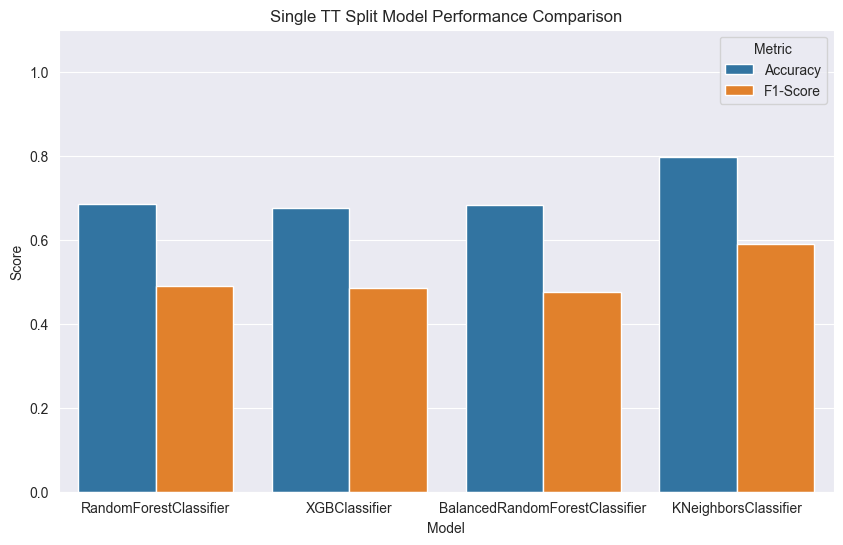

,Model,Accuracy,F1-Score
0,RandomForestClassifier,0.685619,0.490612
1,XGBClassifier,0.675585,0.484638
2,BalancedRandomForestClassifier,0.682274,0.474536
3,KNeighborsClassifier,0.795987,0.589738


In [32]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
results = {}
dfx, dfx_test, dfy ,dfy_test = tt_split(load_data(),0.2)
dfx, dfx_test = one_hot_encoder(dfx,dfx_test)
fitted_models = []
unfitted_models = [
    RandomForestClassifier(),
    XGBClassifier(),
    BalancedRandomForestClassifier(),
    KNeighborsClassifier(n_neighbors = 5)
]

for model in unfitted_models:
    model_name = model.__class__.__name__
    fold_scores = []
    for train_index, test_index in skf.split(dfx, dfy):
        x_train, x_test = dfx.iloc[train_index].copy(), dfx.iloc[test_index].copy()
        y_train, y_test = dfy.iloc[train_index].copy(), dfy.iloc[test_index].copy()
        processed_x_train, processed_x_test, processed_y_train = preprocess(
        dfx = x_train,
        dfx_test= x_test,
        dfy = y_train,
        msn_thresh= True,
        msn_thresh_val= 0.03,
        impute = True,
        imputer_type = 'simple',
        imputer_strategy = 'median',
        unskew= True,
        pca_reduce= True,
        pca_components= 5,
        oversample= True,
        oversampling_type = 'random',
        oversampling_strategy= 'minority'
        )
        model.fit(processed_x_train, processed_y_train)
        predictions = model.predict(processed_x_test)
        fold_scores.append(f1_score(y_test, predictions, average = 'macro'))
    results[model_name] = np.mean(fold_scores)
    print(f'Model {model_name} cross val fold score is \n{results[model_name]}')


processed_dfx, processed_dfx_test, processed_dfy = preprocess(dfx = dfx,
                                                              dfx_test= dfx_test,
                                                              dfy = dfy,
                                                              msn_thresh= True,
                                                              msn_thresh_val= 0.03,
                                                              impute = True,
                                                              imputer_type = 'simple',
                                                              imputer_strategy = 'median',
                                                              unskew= True,
                                                              pca_reduce= True,
                                                              pca_components= 5,
                                                              oversample= True,
                                                              oversampling_type = 'random',
                                                              oversampling_strategy= 'minority'
                                                              )
for unfitted_model in unfitted_models:
    #run_cross_val(unfitted_model, processed_dfx, processed_dfy)
    unfitted_model.fit(processed_dfx, processed_dfy)
    fitted_models.append(unfitted_model)
compare_models(fitted_models, processed_dfx_test, dfy_test)

## All preprocessing enabled, no hyper tuning
Preprocessing:
* baseline steps
* remove cols with more than 97% missing values
* impute missing values with simple median
* unskew via yeo-johnson
* pca with 15 components
* oversample at random


In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
results = {}
dfx, dfx_test, dfy ,dfy_test = tt_split(load_data(),0.2)
dfx, dfx_test = one_hot_encoder(dfx,dfx_test)
fitted_models = []
unfitted_models = [
    RandomForestClassifier(),
    XGBClassifier(),
    BalancedRandomForestClassifier()
]

for model in unfitted_models:
    model_name = model.__class__.__name__
    fold_scores = []
    for train_index, test_index in skf.split(dfx, dfy):
        x_train, x_test = dfx.iloc[train_index].copy(), dfx.iloc[test_index].copy()
        y_train, y_test = dfy.iloc[train_index].copy(), dfy.iloc[test_index].copy()
        processed_x_train, processed_x_test, processed_y_train = preprocess(
        dfx = x_train,
        dfx_test= x_test,
        dfy = y_train,
        msn_thresh= True,
        msn_thresh_val= 0.03,
        impute = True,
        imputer_type = 'simple',
        imputer_strategy = 'median',
        unskew= True,
        pca_reduce= True,
        pca_components= 15,
        oversample= True,
        oversampling_type = 'random',
        oversampling_strategy= 'minority'
        )
        model.fit(processed_x_train, processed_y_train)
        predictions = model.predict(processed_x_test)
        fold_scores.append(f1_score(y_test, predictions, average = 'macro'))
    results[model_name] = np.mean(fold_scores)
    print(f'Model {model_name} cross val fold score is \n{results[model_name]}')


processed_dfx, processed_dfx_test, processed_dfy = preprocess(dfx = dfx,
                                                              dfx_test= dfx_test,
                                                              dfy = dfy,
                                                              msn_thresh= True,
                                                              msn_thresh_val= 0.03,
                                                              impute = True,
                                                              imputer_type = 'simple',
                                                              imputer_strategy = 'median',
                                                              unskew= True,
                                                              pca_reduce= True,
                                                              pca_components= 15,
                                                              oversample= True,
                                                              oversampling_type = 'random',
                                                              oversampling_strategy= 'minority'
                                                              )
for unfitted_model in unfitted_models:
    #run_cross_val(unfitted_model, processed_dfx, processed_dfy)
    unfitted_model.fit(processed_dfx, processed_dfy)
    fitted_models.append(unfitted_model)
compare_models(fitted_models, processed_dfx_test, dfy_test)

## All preprocessing enabled, no hyper tuning
Preprocessing:
* baseline steps
* remove cols with more than 97% missing values
* impute missing values with iterative mean
* unskew via yeo-johnson
* pca with 5 components
* oversample at random


C:\Users\Jess\AppData\Local\Temp\ipykernel_16804\2663247358.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapping)
C:\Users\Jess\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\Jess\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Model RandomForestClassifier cross val fold score is 
0.5571427157459571


C:\Users\Jess\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\Jess\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Model XGBClassifier cross val fold score is 
0.5459368398412103


C:\Users\Jess\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\Jess\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Model BalancedRandomForestClassifier cross val fold score is 
0.55491018338279
RandomForestClassifier score is 
0.7926421404682275
RandomForestClassifier f1 is 
0.5105090832277144
XGBClassifier score is 
0.7558528428093646
XGBClassifier f1 is 
0.509031198686371
BalancedRandomForestClassifier score is 
0.7759197324414716
BalancedRandomForestClassifier f1 is 
0.4892797960484385


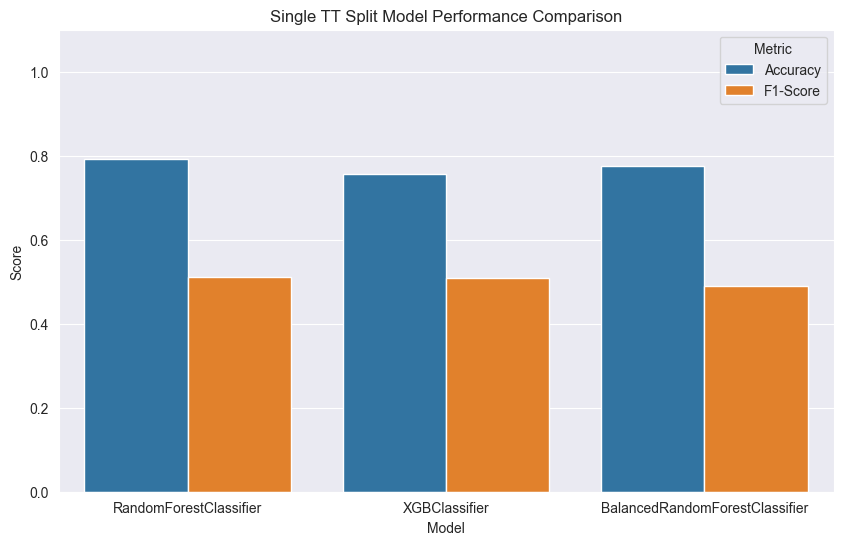

,Model,Accuracy,F1-Score
0,RandomForestClassifier,0.792642,0.510509
1,XGBClassifier,0.755853,0.509031
2,BalancedRandomForestClassifier,0.775920,0.489280


In [27]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
results = {}
dfx, dfx_test, dfy ,dfy_test = tt_split(load_data(),0.2)
dfx, dfx_test = one_hot_encoder(dfx,dfx_test)
fitted_models = []
unfitted_models = [
    RandomForestClassifier(),
    XGBClassifier(),
    BalancedRandomForestClassifier()
]

for model in unfitted_models:
    model_name = model.__class__.__name__
    fold_scores = []
    for train_index, test_index in skf.split(dfx, dfy):
        x_train, x_test = dfx.iloc[train_index].copy(), dfx.iloc[test_index].copy()
        y_train, y_test = dfy.iloc[train_index].copy(), dfy.iloc[test_index].copy()
        processed_x_train, processed_x_test, processed_y_train = preprocess(
        dfx = x_train,
        dfx_test= x_test,
        dfy = y_train,
        msn_thresh= True,
        msn_thresh_val= 0.03,
        impute = True,
        imputer_type = 'iterative',
        imputer_strategy = 'mean',
        unskew= True,
        pca_reduce= True,
        pca_components= 5,
        oversample= True,
        oversampling_type = 'adasyn',
        oversampling_strategy= 'minority'
        )
        model.fit(processed_x_train, processed_y_train)
        predictions = model.predict(processed_x_test)
        fold_scores.append(f1_score(y_test, predictions, average = 'macro'))
    results[model_name] = np.mean(fold_scores)
    print(f'Model {model_name} cross val fold score is \n{results[model_name]}')


processed_dfx, processed_dfx_test, processed_dfy = preprocess(dfx = dfx,
                                                              dfx_test= dfx_test,
                                                              dfy = dfy,
                                                              msn_thresh= True,
                                                              msn_thresh_val= 0.03,
                                                              impute = True,
                                                              imputer_type = 'iterative',
                                                              imputer_strategy = 'mean',
                                                              unskew= True,
                                                              pca_reduce= True,
                                                              pca_components= 5,
                                                              oversample= True,
                                                              oversampling_type = 'adasyn',
                                                              oversampling_strategy= 'minority'
                                                              )
for unfitted_model in unfitted_models:
    #run_cross_val(unfitted_model, processed_dfx, processed_dfy)
    unfitted_model.fit(processed_dfx, processed_dfy)
    fitted_models.append(unfitted_model)
compare_models(fitted_models, processed_dfx_test, dfy_test)

## Some preprocessing enabled, no hyper tuning
Preprocessing:
* baseline steps
* remove cols with more than 97% missing values
* impute missing values with iterative mean
* oversample at random


C:\Users\Jess\AppData\Local\Temp\ipykernel_16804\2663247358.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapping)
C:\Users\Jess\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\Jess\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Model RandomForestClassifier cross val fold score is 
0.5729554226442286


C:\Users\Jess\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\Jess\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Model XGBClassifier cross val fold score is 
0.5736602691673653


C:\Users\Jess\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\Jess\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Model BalancedRandomForestClassifier cross val fold score is 
0.5522773098594491
RandomForestClassifier score is 
0.8260869565217391
RandomForestClassifier f1 is 
0.5321376986037555
XGBClassifier score is 
0.822742474916388
XGBClassifier f1 is 
0.5865101108936726
BalancedRandomForestClassifier score is 
0.8461538461538461
BalancedRandomForestClassifier f1 is 
0.5468502899314708


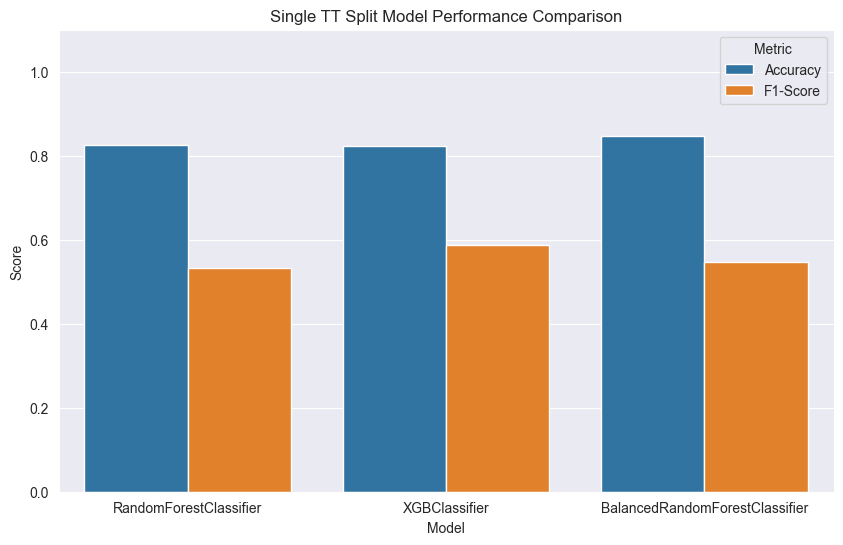

,Model,Accuracy,F1-Score
0,RandomForestClassifier,0.826087,0.532138
1,XGBClassifier,0.822742,0.586510
2,BalancedRandomForestClassifier,0.846154,0.546850


In [28]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
results = {}
dfx, dfx_test, dfy ,dfy_test = tt_split(load_data(),0.2)
dfx, dfx_test = one_hot_encoder(dfx,dfx_test)
fitted_models = []
unfitted_models = [
    RandomForestClassifier(),
    XGBClassifier(),
    BalancedRandomForestClassifier()
]

for model in unfitted_models:
    model_name = model.__class__.__name__
    fold_scores = []
    for train_index, test_index in skf.split(dfx, dfy):
        x_train, x_test = dfx.iloc[train_index].copy(), dfx.iloc[test_index].copy()
        y_train, y_test = dfy.iloc[train_index].copy(), dfy.iloc[test_index].copy()
        processed_x_train, processed_x_test, processed_y_train = preprocess(
        dfx = x_train,
        dfx_test= x_test,
        dfy = y_train,
        msn_thresh= True,
        msn_thresh_val= 0.03,
        impute = True,
        imputer_type = 'iterative',
        imputer_strategy = 'mean',
        unskew= False,
        pca_reduce= False,
        pca_components= 5,
        oversample= True,
        oversampling_type = 'adasyn',
        oversampling_strategy= 'minority'
        )
        model.fit(processed_x_train, processed_y_train)
        predictions = model.predict(processed_x_test)
        fold_scores.append(f1_score(y_test, predictions, average = 'macro'))
    results[model_name] = np.mean(fold_scores)
    print(f'Model {model_name} cross val fold score is \n{results[model_name]}')


processed_dfx, processed_dfx_test, processed_dfy = preprocess(dfx = dfx,
                                                              dfx_test= dfx_test,
                                                              dfy = dfy,
                                                              msn_thresh= True,
                                                              msn_thresh_val= 0.03,
                                                              impute = True,
                                                              imputer_type = 'iterative',
                                                              imputer_strategy = 'mean',
                                                              unskew= False,
                                                              pca_reduce= False,
                                                              pca_components= 5,
                                                              oversample= True,
                                                              oversampling_type = 'adasyn',
                                                              oversampling_strategy= 'minority'
                                                              )
for unfitted_model in unfitted_models:
    #run_cross_val(unfitted_model, processed_dfx, processed_dfy)
    unfitted_model.fit(processed_dfx, processed_dfy)
    fitted_models.append(unfitted_model)
compare_models(fitted_models, processed_dfx_test, dfy_test)

## Some preprocessing enabled, no hyper tuning
Preprocessing:
* baseline steps
* impute simple media
* unskew via yeo-johnson
* pca with 5 components
* oversample at random

In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
results = {}
dfx, dfx_test, dfy ,dfy_test = tt_split(load_data(),0.2)
dfx, dfx_test = one_hot_encoder(dfx,dfx_test)
fitted_models = []
unfitted_models = [
    RandomForestClassifier(),
    XGBClassifier(),
    BalancedRandomForestClassifier()
]

for model in unfitted_models:
    model_name = model.__class__.__name__
    fold_scores = []
    for train_index, test_index in skf.split(dfx, dfy):
        x_train, x_test = dfx.iloc[train_index].copy(), dfx.iloc[test_index].copy()
        y_train, y_test = dfy.iloc[train_index].copy(), dfy.iloc[test_index].copy()
        processed_x_train, processed_x_test, processed_y_train = preprocess(
        dfx = x_train,
        dfx_test= x_test,
        dfy = y_train,
        msn_thresh= False,
        msn_thresh_val= 0.03,
        impute = True,
        imputer_type = 'simple',
        imputer_strategy = 'median',
        unskew= True,
        pca_reduce= True,
        pca_components= 5,
        oversample= True,
        oversampling_type = 'random',
        oversampling_strategy= 'minority'
        )
        model.fit(processed_x_train, processed_y_train)
        predictions = model.predict(processed_x_test)
        fold_scores.append(f1_score(y_test, predictions, average = 'macro'))
    results[model_name] = np.mean(fold_scores)
    print(f'Model {model_name} cross val fold score is \n{results[model_name]}')


processed_dfx, processed_dfx_test, processed_dfy = preprocess(dfx = dfx,
                                                              dfx_test= dfx_test,
                                                              dfy = dfy,
                                                              msn_thresh= False,
                                                              msn_thresh_val= 0.03,
                                                              impute = True,
                                                              imputer_type = 'simple',
                                                              imputer_strategy = 'median',
                                                              unskew= True,
                                                              pca_reduce= True,
                                                              pca_components= 5,
                                                              oversample= True,
                                                              oversampling_type = 'random',
                                                              oversampling_strategy= 'minority'
                                                              )
for unfitted_model in unfitted_models:
    #run_cross_val(unfitted_model, processed_dfx, processed_dfy)
    unfitted_model.fit(processed_dfx, processed_dfy)
    fitted_models.append(unfitted_model)
compare_models(fitted_models, processed_dfx_test, dfy_test)

## Some preprocessing enabled, no hyper tuning
Preprocessing:
* baseline steps
* unskew via yeo-johnson
* oversample at random

In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
results = {}
dfx, dfx_test, dfy ,dfy_test = tt_split(load_data(),0.2)
dfx, dfx_test = one_hot_encoder(dfx,dfx_test)
fitted_models = []
unfitted_models = [
    RandomForestClassifier(),
    XGBClassifier(),
    BalancedRandomForestClassifier()
]

for model in unfitted_models:
    model_name = model.__class__.__name__
    fold_scores = []
    for train_index, test_index in skf.split(dfx, dfy):
        x_train, x_test = dfx.iloc[train_index].copy(), dfx.iloc[test_index].copy()
        y_train, y_test = dfy.iloc[train_index].copy(), dfy.iloc[test_index].copy()
        processed_x_train, processed_x_test, processed_y_train = preprocess(
        dfx = x_train,
        dfx_test= x_test,
        dfy = y_train,
        msn_thresh= True,
        msn_thresh_val= 0.03,
        impute = False,
        imputer_type = 'simple',
        imputer_strategy = 'median',
        unskew= True,
        pca_reduce= False,
        pca_components= 5,
        oversample= True,
        oversampling_type = 'random',
        oversampling_strategy= 'minority'
        )
        model.fit(processed_x_train, processed_y_train)
        predictions = model.predict(processed_x_test)
        fold_scores.append(f1_score(y_test, predictions, average = 'macro'))
    results[model_name] = np.mean(fold_scores)
    print(f'Model {model_name} cross val fold score is \n{results[model_name]}')


processed_dfx, processed_dfx_test, processed_dfy = preprocess(dfx = dfx,
                                                              dfx_test= dfx_test,
                                                              dfy = dfy,
                                                              msn_thresh= True,
                                                              msn_thresh_val= 0.03,
                                                              impute = False,
                                                              imputer_type = 'simple',
                                                              imputer_strategy = 'median',
                                                              unskew= True,
                                                              pca_reduce = False,
                                                              pca_components= 5,
                                                              oversample= True,
                                                              oversampling_type = 'random',
                                                              oversampling_strategy= 'minority'
                                                              )
for unfitted_model in unfitted_models:
    #run_cross_val(unfitted_model, processed_dfx, processed_dfy)
    unfitted_model.fit(processed_dfx, processed_dfy)
    fitted_models.append(unfitted_model)
compare_models(fitted_models, processed_dfx_test, dfy_test)

## Some preprocessing enabled, no hyper tuning
Preprocessing:
* baseline steps
* drop 97% missing cols
* oversample at random

In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
results = {}
dfx, dfx_test, dfy ,dfy_test = tt_split(load_data(),0.2)
dfx, dfx_test = one_hot_encoder(dfx,dfx_test)
fitted_models = []
unfitted_models = [
    RandomForestClassifier(),
    XGBClassifier(),
    BalancedRandomForestClassifier()
]

for model in unfitted_models:
    model_name = model.__class__.__name__
    fold_scores = []
    for train_index, test_index in skf.split(dfx, dfy):
        x_train, x_test = dfx.iloc[train_index].copy(), dfx.iloc[test_index].copy()
        y_train, y_test = dfy.iloc[train_index].copy(), dfy.iloc[test_index].copy()
        processed_x_train, processed_x_test, processed_y_train = preprocess(
        dfx = x_train,
        dfx_test= x_test,
        dfy = y_train,
        msn_thresh= True,
        msn_thresh_val= 0.03,
        impute = False,
        imputer_type = 'simple',
        imputer_strategy = 'median',
        unskew= False,
        pca_reduce= False,
        pca_components= 5,
        oversample= True,
        oversampling_type = 'random',
        oversampling_strategy= 'minority'
        )
        model.fit(processed_x_train, processed_y_train)
        predictions = model.predict(processed_x_test)
        fold_scores.append(f1_score(y_test, predictions, average = 'macro'))
    results[model_name] = np.mean(fold_scores)
    print(f'Model {model_name} cross val fold score is \n{results[model_name]}')


processed_dfx, processed_dfx_test, processed_dfy = preprocess(dfx = dfx,
                                                              dfx_test= dfx_test,
                                                              dfy = dfy,
                                                              msn_thresh= True,
                                                              msn_thresh_val= 0.03,
                                                              impute = False,
                                                              imputer_type = 'simple',
                                                              imputer_strategy = 'median',
                                                              unskew= False,
                                                              pca_reduce= False,
                                                              pca_components= 5,
                                                              oversample= True,
                                                              oversampling_type = 'random',
                                                              oversampling_strategy= 'minority'
                                                              )
for unfitted_model in unfitted_models:
    #run_cross_val(unfitted_model, processed_dfx, processed_dfy)
    unfitted_model.fit(processed_dfx, processed_dfy)
    fitted_models.append(unfitted_model)
compare_models(fitted_models, processed_dfx_test, dfy_test)

## Some preprocessing enabled, no hyper tuning
Preprocessing:
* baseline steps
* drop 97% missing cols
* impute simple median
* oversample ADASYN

In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
results = {}
dfx, dfx_test, dfy ,dfy_test = tt_split(load_data(),0.2)
dfx, dfx_test = one_hot_encoder(dfx,dfx_test)
fitted_models = []
unfitted_models = [
    RandomForestClassifier(),
    XGBClassifier(),
    BalancedRandomForestClassifier()
]

for model in unfitted_models:
    model_name = model.__class__.__name__
    fold_scores = []
    for train_index, test_index in skf.split(dfx, dfy):
        x_train, x_test = dfx.iloc[train_index].copy(), dfx.iloc[test_index].copy()
        y_train, y_test = dfy.iloc[train_index].copy(), dfy.iloc[test_index].copy()
        processed_x_train, processed_x_test, processed_y_train = preprocess(
        dfx = x_train,
        dfx_test= x_test,
        dfy = y_train,
        msn_thresh= True,
        msn_thresh_val= 0.03,
        impute = True,
        imputer_type = 'simple',
        imputer_strategy = 'median',
        unskew= False,
        pca_reduce= False,
        pca_components= 5,
        oversample= True,
        oversampling_type = 'adasyn',
        oversampling_strategy= 'minority'
        )
        model.fit(processed_x_train, processed_y_train)
        predictions = model.predict(processed_x_test)
        fold_scores.append(f1_score(y_test, predictions, average = 'macro'))
    results[model_name] = np.mean(fold_scores)
    print(f'Model {model_name} cross val fold score is \n{results[model_name]}')


processed_dfx, processed_dfx_test, processed_dfy = preprocess(dfx = dfx,
                                                              dfx_test= dfx_test,
                                                              dfy = dfy,
                                                              msn_thresh= True,
                                                              msn_thresh_val= 0.03,
                                                              impute = True,
                                                              imputer_type = 'simple',
                                                              imputer_strategy = 'median',
                                                              unskew= False,
                                                              pca_reduce= False,
                                                              pca_components= 5,
                                                              oversample= True,
                                                              oversampling_type = 'adasyn',
                                                              oversampling_strategy= 'minority'
                                                              )
for unfitted_model in unfitted_models:
    #run_cross_val(unfitted_model, processed_dfx, processed_dfy)
    unfitted_model.fit(processed_dfx, processed_dfy)
    fitted_models.append(unfitted_model)
compare_models(fitted_models, processed_dfx_test, dfy_test)

## Some preprocessing enabled, no hyper tuning
Preprocessing:
* baseline steps
* drop 97% missing cols
* impute itertive median
* oversample ADASYN

In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
results = {}
dfx, dfx_test, dfy ,dfy_test = tt_split(load_data(),0.2)
dfx, dfx_test = one_hot_encoder(dfx,dfx_test)
fitted_models = []
unfitted_models = [
    RandomForestClassifier(),
    XGBClassifier(),
    BalancedRandomForestClassifier()
]

for model in unfitted_models:
    model_name = model.__class__.__name__
    fold_scores = []
    for train_index, test_index in skf.split(dfx, dfy):
        x_train, x_test = dfx.iloc[train_index].copy(), dfx.iloc[test_index].copy()
        y_train, y_test = dfy.iloc[train_index].copy(), dfy.iloc[test_index].copy()
        processed_x_train, processed_x_test, processed_y_train = preprocess(
        dfx = x_train,
        dfx_test= x_test,
        dfy = y_train,
        msn_thresh= True,
        msn_thresh_val= 0.03,
        impute = True,
        imputer_type = 'iterative',
        imputer_strategy = 'median',
        unskew= False,
        pca_reduce= False,
        pca_components= 5,
        oversample= True,
        oversampling_type = 'adasyn',
        oversampling_strategy= 'minority'
        )
        model.fit(processed_x_train, processed_y_train)
        predictions = model.predict(processed_x_test)
        fold_scores.append(f1_score(y_test, predictions, average = 'macro'))
    results[model_name] = np.mean(fold_scores)
    print(f'Model {model_name} cross val fold score is \n{results[model_name]}')


processed_dfx, processed_dfx_test, processed_dfy = preprocess(dfx = dfx,
                                                              dfx_test= dfx_test,
                                                              dfy = dfy,
                                                              msn_thresh= True,
                                                              msn_thresh_val= 0.03,
                                                              impute = True,
                                                              imputer_type = 'iterative',
                                                              imputer_strategy = 'median',
                                                              unskew= False,
                                                              pca_reduce= False,
                                                              pca_components= 5,
                                                              oversample= True,
                                                              oversampling_type = 'adasyn',
                                                              oversampling_strategy= 'minority'
                                                              )
for unfitted_model in unfitted_models:
    #run_cross_val(unfitted_model, processed_dfx, processed_dfy)
    unfitted_model.fit(processed_dfx, processed_dfy)
    fitted_models.append(unfitted_model)
compare_models(fitted_models, processed_dfx_test, dfy_test)

## Some preprocessing enabled, no hyper tuning
Preprocessing:
* baseline steps
* drop 97% missing cols
* impute itertive median
* unskew yj
* oversample ADASYN

In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
results = {}
dfx, dfx_test, dfy ,dfy_test = tt_split(load_data(),0.2)
dfx, dfx_test = one_hot_encoder(dfx,dfx_test)
fitted_models = []
unfitted_models = [
    RandomForestClassifier(),
    XGBClassifier(),
    BalancedRandomForestClassifier()
]

for model in unfitted_models:
    model_name = model.__class__.__name__
    fold_scores = []
    for train_index, test_index in skf.split(dfx, dfy):
        x_train, x_test = dfx.iloc[train_index].copy(), dfx.iloc[test_index].copy()
        y_train, y_test = dfy.iloc[train_index].copy(), dfy.iloc[test_index].copy()
        processed_x_train, processed_x_test, processed_y_train = preprocess(
        dfx = x_train,
        dfx_test= x_test,
        dfy = y_train,
        msn_thresh= True,
        msn_thresh_val= 0.03,
        impute = True,
        imputer_type = 'iterative',
        imputer_strategy = 'median',
        unskew= True,
        pca_reduce= False,
        pca_components= 5,
        oversample= True,
        oversampling_type = 'adasyn',
        oversampling_strategy= 'minority'
        )
        model.fit(processed_x_train, processed_y_train)
        predictions = model.predict(processed_x_test)
        fold_scores.append(f1_score(y_test, predictions, average = 'macro'))
    results[model_name] = np.mean(fold_scores)
    print(f'Model {model_name} cross val fold score is \n{results[model_name]}')


processed_dfx, processed_dfx_test, processed_dfy = preprocess(dfx = dfx,
                                                              dfx_test= dfx_test,
                                                              dfy = dfy,
                                                              msn_thresh= True,
                                                              msn_thresh_val= 0.03,
                                                              impute = True,
                                                              imputer_type = 'iterative',
                                                              imputer_strategy = 'median',
                                                              unskew= True,
                                                              pca_reduce= False,
                                                              pca_components= 5,
                                                              oversample= True,
                                                              oversampling_type = 'adasyn',
                                                              oversampling_strategy= 'minority'
                                                              )
for unfitted_model in unfitted_models:
    #run_cross_val(unfitted_model, processed_dfx, processed_dfy)
    unfitted_model.fit(processed_dfx, processed_dfy)
    fitted_models.append(unfitted_model)
compare_models(fitted_models, processed_dfx_test, dfy_test)

In [ ]:
from skopt.space import Real, Integer
from scipy.stats import uniform,poisson
from skopt import BayesSearchCV
parameters = {
    'n_estimators':Integer(50,1000,prior='uniform'),
    'learning_rate':Real(0.0001,1, prior ='log-uniform'),
    'max_depth':Integer(1,10,prior='uniform'),
    'reg_alpha':Real(0.0001,2,prior='log-uniform'),
    'reg_lambda':Real(0.0001,2,prior='log-uniform'),
}
b_opt = BayesSearchCV(XGBClassifier(random_state =1), parameters, cv = 5, n_jobs = -1, n_iter = 10)
b_opt.fit(dfxt, dfyt)

best_params = b_opt.best_params_
best_params

In [ ]:
from skopt.space import Real, Integer
from scipy.stats import uniform,poisson
from skopt import BayesSearchCV
dfx, dfx_test, dfy ,dfy_test = tt_split(load_data(),0.2)

parameters = {
    'n_estimators':Integer(50,1000,prior='uniform'),
    'learning_rate':Real(0.0001,1, prior ='log-uniform'),
    'max_depth':Integer(1,10,prior='uniform'),
    'reg_alpha':Real(0.0001,2,prior='log-uniform'),
    'reg_lambda':Real(0.0001,2,prior='log-uniform'),
}
b_opt = BayesSearchCV(XGBClassifier(random_state =1), parameters, cv = 5, n_jobs = -1, n_iter = 10)
b_opt.fit(dfx, dfy)

best_params = b_opt.best_params_
best_params